In [4]:
import pandas as pd

In [8]:
import os

os.listdir("../data/raw/rent")

['.DS_Store', 'private-rental-report-2025-12.xlsx']

In [9]:
df = pd.read_excel("../data/raw/rent/private-rental-report-2025-12.xlsx")

print(df.head())
print(df.columns)
print(df.shape)

                                          Unnamed: 0 Unnamed: 1 Unnamed: 2  \
0                                                NaN        NaN        NaN   
1  Source: Rental Bond Data Set of the Tenancies ...        NaN        NaN   
2                                                NaN        NaN        NaN   
3                                             Notes:        NaN        NaN   
4  1. Excludes bonds that have been "cancelled" o...        NaN        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   
3        NaN        NaN        NaN        NaN        NaN        NaN   
4        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9  ... Unnamed: 17 Unnamed: 18 Unnamed: 19 Unnamed: 20 Unnamed: 21  \
0        NaN  ...      

In [18]:
import pandas as pd
import numpy as np

file_path = "../data/raw/rent/private-rental-report-2025-12.xlsx"

# Read the Excel file without assuming headers
raw = pd.read_excel(file_path, header=None)

# Show rows 12 to 16 so we can inspect header area clearly
raw.iloc[12:17, :]

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
12,NaN,Flats/Units,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Flats/Units Count,...,NaN,NaN,Houses Count,Houses Median,Other/Unknown,NaN,Other/Unknown Count,Other/Unknown Median,Total Count,Total Median
13,NaN,1 bedroom,NaN,2 bedrooms,NaN,3 bedrooms,NaN,4+ bedrooms,NaN,NaN,...,4+ bedrooms,NaN,NaN,NaN,Not applicable,NaN,NaN,NaN,NaN,NaN
14,NaN,Count,Median,Count,Median,Count,Median,Count,Median,NaN,...,Count,Median,NaN,NaN,Count,Median,NaN,NaN,NaN,NaN
15,Metro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Aberfoyle Park,NaN,NaN,*,450,*,610,NaN,NaN,*,...,*,700,20,635,NaN,NaN,NaN,NaN,25,630


In [19]:
# Create a working copy from the actual data rows
# Based on your screenshot, suburb data starts from row 15
rent_df = raw.iloc[15:].copy()

# Keep the first column as Suburb
rent_df = rent_df.rename(columns={0: "Suburb"})

# Remove rows where Suburb is empty
rent_df = rent_df[rent_df["Suburb"].notna()]

# Replace "*" with missing values
rent_df = rent_df.replace("*", np.nan)

# Preview
rent_df.head()

/var/folders/rj/61xn_nz93897n4qbctp1fpzh0000gn/T/ipykernel_35977/1729325932.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rent_df = rent_df.replace("*", np.nan)


,Suburb,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
15,Metro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Aberfoyle Park,NaN,NaN,NaN,450.0,NaN,610.0,NaN,NaN,NaN,...,NaN,700.0,20.0,635.0,NaN,NaN,NaN,NaN,25.0,630.0
17,Adelaide,540.0,469.0,255.0,640.0,40.0,770.0,NaN,270.0,840.0,...,10.0,277.5,85.0,650.0,125.0,246.4,125.0,246.4,1050.0,514.5
18,Albert Park,NaN,NaN,NaN,480.0,NaN,NaN,NaN,NaN,NaN,...,NaN,750.0,15.0,610.0,NaN,NaN,NaN,NaN,15.0,600.0
19,Alberton,NaN,370.0,NaN,520.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.0,520.0,NaN,NaN,NaN,NaN,10.0,520.0


In [20]:
rent_df.shape

(643, 27)

In [21]:
rent_df.head(10)

,Suburb,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
15,Metro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Aberfoyle Park,NaN,NaN,NaN,450.0,NaN,610.0,NaN,NaN,NaN,...,NaN,700.0,20.0,635.0,NaN,NaN,NaN,NaN,25.0,630.0
17,Adelaide,540.0,469.0,255.0,640.0,40.0,770.0,NaN,270.0,840.0,...,10.0,277.5,85.0,650.0,125.0,246.4,125.0,246.4,1050.0,514.5
18,Albert Park,NaN,NaN,NaN,480.0,NaN,NaN,NaN,NaN,NaN,...,NaN,750.0,15.0,610.0,NaN,NaN,NaN,NaN,15.0,600.0
19,Alberton,NaN,370.0,NaN,520.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.0,520.0,NaN,NaN,NaN,NaN,10.0,520.0
20,Aldgate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,790.0,5.0,650.0,NaN,NaN,NaN,NaN,5.0,650.0
21,Aldinga,NaN,445.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,650.0,NaN,650.0,NaN,NaN,NaN,NaN,NaN,650.0
22,Aldinga Beach,NaN,412.5,NaN,510.0,NaN,530.0,NaN,NaN,10.0,...,15.0,650.0,60.0,600.0,6.0,175.0,6.0,175.0,80.0,577.5
23,Allenby Gardens,NaN,430.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,980.0,15.0,685.0,NaN,NaN,NaN,NaN,15.0,640.0
24,Andrews Farm,NaN,225.0,NaN,450.0,NaN,NaN,NaN,NaN,NaN,...,30.0,600.0,100.0,560.0,NaN,230.0,NaN,230.0,105.0,550.0


In [22]:
raw.iloc[12:15, :]

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
12,NaN,Flats/Units,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Flats/Units Count,...,NaN,NaN,Houses Count,Houses Median,Other/Unknown,NaN,Other/Unknown Count,Other/Unknown Median,Total Count,Total Median
13,NaN,1 bedroom,NaN,2 bedrooms,NaN,3 bedrooms,NaN,4+ bedrooms,NaN,NaN,...,4+ bedrooms,NaN,NaN,NaN,Not applicable,NaN,NaN,NaN,NaN,NaN
14,NaN,Count,Median,Count,Median,Count,Median,Count,Median,NaN,...,Count,Median,NaN,NaN,Count,Median,NaN,NaN,NaN,NaN


In [26]:
cleaned_rent = rent_df[[
    "Suburb", 1, 2, 3, 4, 5, 6, 9, 10, 19, 20, 25, 26
]].copy()

cleaned_rent.columns = [
    "Suburb",
    "Unit_1BR_Count",
    "Unit_1BR_Median",
    "Unit_2BR_Count",
    "Unit_2BR_Median",
    "Unit_3BR_Count",
    "Unit_3BR_Median",
    "Unit_Total_Count",
    "Unit_Total_Median",
    "House_Total_Count",
    "House_Total_Median",
    "Total_Count",
    "Total_Median"
]

cleaned_rent.head()

,Suburb,Unit_1BR_Count,Unit_1BR_Median,Unit_2BR_Count,Unit_2BR_Median,Unit_3BR_Count,Unit_3BR_Median,Unit_Total_Count,Unit_Total_Median,House_Total_Count,House_Total_Median,Total_Count,Total_Median
15,Metro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Aberfoyle Park,NaN,NaN,NaN,450.0,NaN,610.0,NaN,500.0,20.0,635.0,25.0,630.0
17,Adelaide,540.0,469.0,255.0,640.0,40.0,770.0,840.0,539.0,85.0,650.0,1050.0,514.5
18,Albert Park,NaN,NaN,NaN,480.0,NaN,NaN,NaN,480.0,15.0,610.0,15.0,600.0
19,Alberton,NaN,370.0,NaN,520.0,NaN,NaN,NaN,440.0,5.0,520.0,10.0,520.0


In [27]:
cleaned_rent = cleaned_rent[cleaned_rent["Suburb"] != "Metro"]

cleaned_rent.head()

,Suburb,Unit_1BR_Count,Unit_1BR_Median,Unit_2BR_Count,Unit_2BR_Median,Unit_3BR_Count,Unit_3BR_Median,Unit_Total_Count,Unit_Total_Median,House_Total_Count,House_Total_Median,Total_Count,Total_Median
16,Aberfoyle Park,NaN,NaN,NaN,450.0,NaN,610.0,NaN,500.0,20.0,635.0,25.0,630.0
17,Adelaide,540.0,469.0,255.0,640.0,40.0,770.0,840.0,539.0,85.0,650.0,1050.0,514.5
18,Albert Park,NaN,NaN,NaN,480.0,NaN,NaN,NaN,480.0,15.0,610.0,15.0,600.0
19,Alberton,NaN,370.0,NaN,520.0,NaN,NaN,NaN,440.0,5.0,520.0,10.0,520.0
20,Aldgate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,650.0,5.0,650.0


In [28]:
cleaned_rent.to_csv("../data/processed/cleaned_rent_2025_12.csv", index=False)

In [29]:
import os

os.listdir("../data/processed")

['cleaned_rent_2025_12.csv']

In [30]:
cleaned_rent = cleaned_rent.reset_index(drop=True)
cleaned_rent.head()

,Suburb,Unit_1BR_Count,Unit_1BR_Median,Unit_2BR_Count,Unit_2BR_Median,Unit_3BR_Count,Unit_3BR_Median,Unit_Total_Count,Unit_Total_Median,House_Total_Count,House_Total_Median,Total_Count,Total_Median
0,Aberfoyle Park,NaN,NaN,NaN,450.0,NaN,610.0,NaN,500.0,20.0,635.0,25.0,630.0
1,Adelaide,540.0,469.0,255.0,640.0,40.0,770.0,840.0,539.0,85.0,650.0,1050.0,514.5
2,Albert Park,NaN,NaN,NaN,480.0,NaN,NaN,NaN,480.0,15.0,610.0,15.0,600.0
3,Alberton,NaN,370.0,NaN,520.0,NaN,NaN,NaN,440.0,5.0,520.0,10.0,520.0
4,Aldgate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,650.0,5.0,650.0


In [31]:
cleaned_rent.to_csv("../data/processed/cleaned_rent_2025_12.csv", index=False)

In [32]:
cleaned_rent.isna().sum()

Suburb                  0
Unit_1BR_Count        622
Unit_1BR_Median       441
Unit_2BR_Count        536
Unit_2BR_Median       328
Unit_3BR_Count        624
Unit_3BR_Median       457
Unit_Total_Count      489
Unit_Total_Median     266
House_Total_Count     296
House_Total_Median     21
Total_Count           252
Total_Median            1
dtype: int64

In [33]:
cleaned_rent[["Suburb", "Unit_Total_Median", "House_Total_Median", "Total_Median", "Total_Count"]].head(20)

,Suburb,Unit_Total_Median,House_Total_Median,Total_Median,Total_Count
0,Aberfoyle Park,500.0,635.0,630.0,25.0
1,Adelaide,539.0,650.0,514.5,1050.0
2,Albert Park,480.0,610.0,600.0,15.0
3,Alberton,440.0,520.0,520.0,10.0
4,Aldgate,NaN,650.0,650.0,5.0
5,Aldinga,445.0,650.0,650.0,NaN
6,Aldinga Beach,485.0,600.0,577.5,80.0
7,Allenby Gardens,430.0,685.0,640.0,15.0
8,Andrews Farm,337.5,560.0,550.0,105.0
9,Angle Park,NaN,520.7,520.7,NaN


In [36]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 16.9 MB/s  0:00:004.7 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


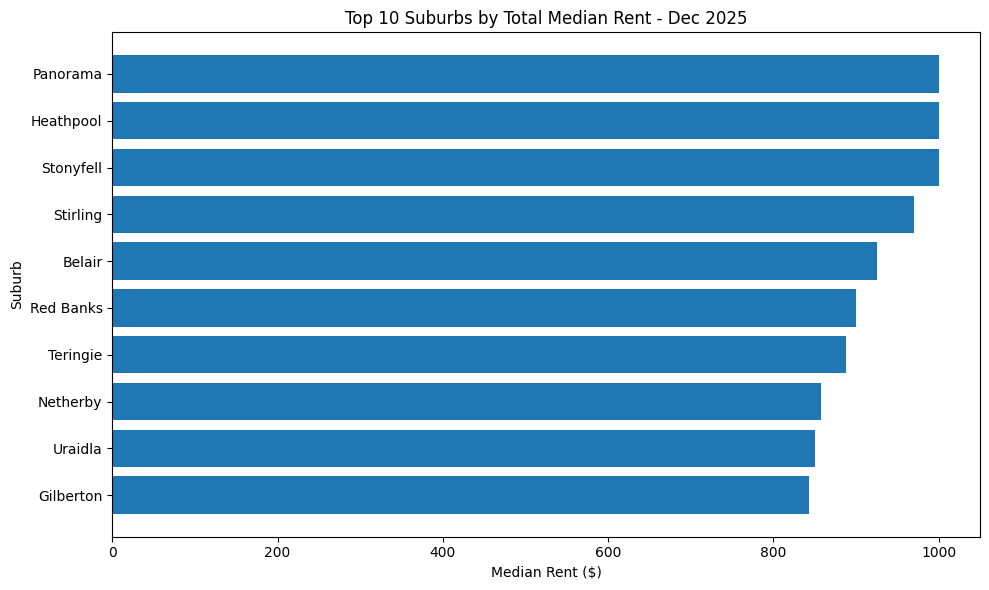

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

rent = pd.read_csv("../data/processed/cleaned_rent_2025_12.csv")

top_rent = rent.dropna(subset=["Total_Median"]).sort_values("Total_Median", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_rent["Suburb"], top_rent["Total_Median"])
plt.xlabel("Median Rent ($)")
plt.ylabel("Suburb")
plt.title("Top 10 Suburbs by Total Median Rent - Dec 2025")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

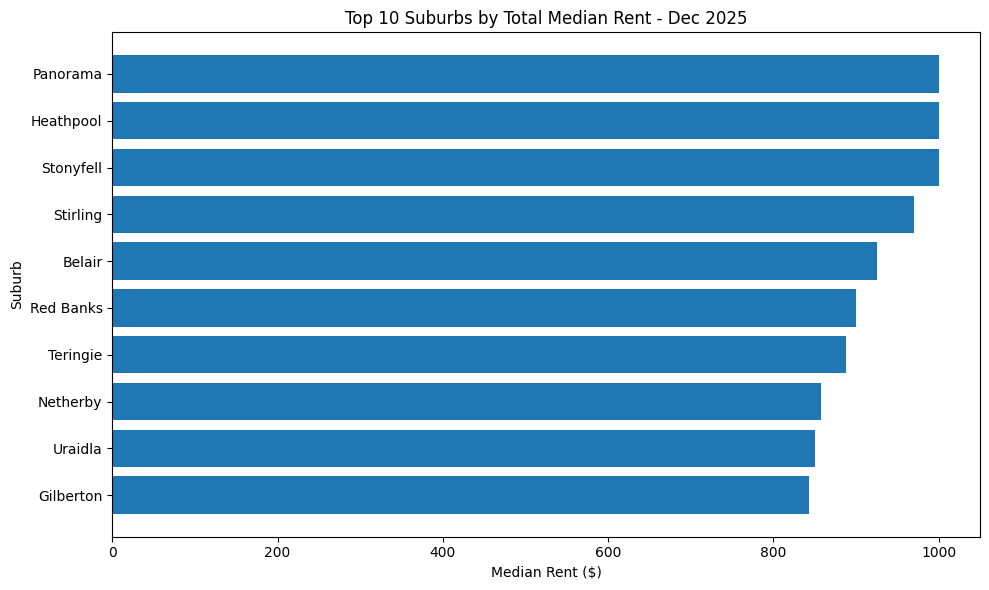

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

rent = pd.read_csv("../data/processed/cleaned_rent_2025_12.csv")

top_rent = (
    rent
    .dropna(subset=["Total_Median"])
    .sort_values("Total_Median", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(top_rent["Suburb"], top_rent["Total_Median"])
plt.xlabel("Median Rent ($)")
plt.ylabel("Suburb")
plt.title("Top 10 Suburbs by Total Median Rent - Dec 2025")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("../docs/top_10_suburbs_median_rent_dec_2025.png", dpi=300)

plt.show()

In [40]:
plt.savefig("../docs/top_10_suburbs_median_rent_dec_2025.png", dpi=300)

<Figure size 640x480 with 0 Axes>

## Dataset 2 — Building Approvals

In [1]:
import os

os.listdir("../data/raw/approvals")

['8731004.xlsx']

In [2]:
import pandas as pd

approval_file = "../data/raw/approvals/8731004.xlsx"

approvals_raw = pd.read_excel(approval_file, header=None)

approvals_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Time Series Workbook,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,"8731.0 Building Approvals, Australia",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,"Table 04. Number of dwelling units approved, b...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,Enquiries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Data Item Description,NaN,NaN,Series Type,Series ID,Series Start,Series End,No. Obs.,Unit,Data Type,Freq.,Collection Month


In [3]:
approvals = pd.read_excel(approval_file, header=9)

approvals.head()

,Data Item Description,Unnamed: 1,Unnamed: 2,Series Type,Series ID,Series Start,Series End,No. Obs.,Unit,Data Type,Freq.,Collection Month
0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418704W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
2,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418757A,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
3,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421567W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
4,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421628R,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0


In [4]:
approvals.columns

Index(['Data Item Description', 'Unnamed: 1', 'Unnamed: 2', 'Series Type',
       'Series ID', 'Series Start', 'Series End', 'No. Obs.', 'Unit',
       'Data Type', 'Freq.', 'Collection Month'],
      dtype='object')

In [5]:
approvals.head(15)

,Data Item Description,Unnamed: 1,Unnamed: 2,Series Type,Series ID,Series Start,Series End,No. Obs.,Unit,Data Type,Freq.,Collection Month
0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418704W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
2,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418757A,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
3,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421567W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
4,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421628R,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
5,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A422402T,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
6,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A422466C,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
7,Total number of dwelling units ; South Austra...,NaN,NaN,Seasonally Adjusted,A418707C,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
8,Total number of dwelling units ; South Austra...,NaN,NaN,Seasonally Adjusted,A418760R,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
9,Total number of dwelling units ; South Austra...,NaN,NaN,Seasonally Adjusted,A422408F,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0


In [6]:
approvals.shape

(19, 12)

In [7]:
approvals.iloc[:5, :20]

,Data Item Description,Unnamed: 1,Unnamed: 2,Series Type,Series ID,Series Start,Series End,No. Obs.,Unit,Data Type,Freq.,Collection Month
0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418704W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
2,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418757A,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
3,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421567W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
4,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421628R,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0


In [8]:
approvals.iloc[:5, 20:40]

""
0
1
2
3
4


In [9]:
approvals = pd.read_excel(approval_file, header=9)

approvals.head()

,Data Item Description,Unnamed: 1,Unnamed: 2,Series Type,Series ID,Series Start,Series End,No. Obs.,Unit,Data Type,Freq.,Collection Month
0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418704W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
2,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418757A,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
3,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421567W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
4,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421628R,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0


In [10]:
approvals.columns

Index(['Data Item Description', 'Unnamed: 1', 'Unnamed: 2', 'Series Type',
       'Series ID', 'Series Start', 'Series End', 'No. Obs.', 'Unit',
       'Data Type', 'Freq.', 'Collection Month'],
      dtype='object')

In [11]:
approvals.iloc[:10, :25]

,Data Item Description,Unnamed: 1,Unnamed: 2,Series Type,Series ID,Series Start,Series End,No. Obs.,Unit,Data Type,Freq.,Collection Month
0,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN
1,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418704W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
2,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A418757A,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
3,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421567W,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
4,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A421628R,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
5,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A422402T,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
6,Total number of dwelling units ; South Austra...,NaN,NaN,Original,A422466C,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
7,Total number of dwelling units ; South Austra...,NaN,NaN,Seasonally Adjusted,A418707C,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
8,Total number of dwelling units ; South Austra...,NaN,NaN,Seasonally Adjusted,A418760R,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0
9,Total number of dwelling units ; South Austra...,NaN,NaN,Seasonally Adjusted,A422408F,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0


In [12]:
approvals.columns.tolist()

['Data Item Description',
 'Unnamed: 1',
 'Unnamed: 2',
 'Series Type',
 'Series ID',
 'Series Start',
 'Series End',
 'No. Obs.',
 'Unit',
 'Data Type',
 'Freq.',
 'Collection Month']

In [13]:
approvals.iloc[:10, 25:45]

""
0
1
2
3
4
5
6
7
8
9


In [14]:
approvals.iloc[:10, 45:70]

""
0
1
2
3
4
5
6
7
8
9


In [15]:
pd.set_option("display.max_colwidth", 200)

approvals[["Data Item Description", "Series Type", "Series ID"]].head(20)

,Data Item Description,Series Type,Series ID
0,NaN,NaN,NaN
1,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Original,A418704W
2,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Original,A418757A
3,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Private Sector ;,Original,A421567W
4,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Total Sectors ;,Original,A421628R
5,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Original,A422402T
6,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,Original,A422466C
7,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Seasonally Adjusted,A418707C
8,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Seasonally Adjusted,A418760R
9,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Seasonally Adjusted,A422408F


In [16]:
approvals.columns.tolist()

['Data Item Description',
 'Unnamed: 1',
 'Unnamed: 2',
 'Series Type',
 'Series ID',
 'Series Start',
 'Series End',
 'No. Obs.',
 'Unit',
 'Data Type',
 'Freq.',
 'Collection Month']

In [17]:
approvals.iloc[:10, 25:45]

""
0
1
2
3
4
5
6
7
8
9


In [18]:
approvals[["Data Item Description", "Series Type", "Series ID"]].head(20)

,Data Item Description,Series Type,Series ID
0,NaN,NaN,NaN
1,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Original,A418704W
2,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Original,A418757A
3,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Private Sector ;,Original,A421567W
4,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Total Sectors ;,Original,A421628R
5,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Original,A422402T
6,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,Original,A422466C
7,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Seasonally Adjusted,A418707C
8,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Seasonally Adjusted,A418760R
9,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Seasonally Adjusted,A422408F


In [19]:
approvals.columns.tolist()

['Data Item Description',
 'Unnamed: 1',
 'Unnamed: 2',
 'Series Type',
 'Series ID',
 'Series Start',
 'Series End',
 'No. Obs.',
 'Unit',
 'Data Type',
 'Freq.',
 'Collection Month']

In [20]:
approvals.iloc[6, 0:30]

Data Item Description    Total number of dwelling units ;  South Australia ;  Total (Type of Building) ;  Total Sectors ;
Unnamed: 1                                                                                                            NaN
Unnamed: 2                                                                                                            NaN
Series Type                                                                                                      Original
Series ID                                                                                                        A422466C
Series Start                                                                                          1983-07-01 00:00:00
Series End                                                                                            2026-04-01 00:00:00
No. Obs.                                                                                                            514.0
Unit                    

In [21]:
approvals.iloc[6, 0:30]

Data Item Description    Total number of dwelling units ;  South Australia ;  Total (Type of Building) ;  Total Sectors ;
Unnamed: 1                                                                                                            NaN
Unnamed: 2                                                                                                            NaN
Series Type                                                                                                      Original
Series ID                                                                                                        A422466C
Series Start                                                                                          1983-07-01 00:00:00
Series End                                                                                            2026-04-01 00:00:00
No. Obs.                                                                                                            514.0
Unit                    

In [22]:
approvals.iloc[6, 30:60]

Series([], Name: 6, dtype: object)

In [23]:
# Select the row for total dwelling approvals, South Australia, total sectors
total_approvals_row = approvals[
    (approvals["Series ID"] == "A422466C") &
    (approvals["Series Type"] == "Original")
]

total_approvals_row

,Data Item Description,Unnamed: 1,Unnamed: 2,Series Type,Series ID,Series Start,Series End,No. Obs.,Unit,Data Type,Freq.,Collection Month
6,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,NaN,NaN,Original,A422466C,1983-07-01,2026-04-01,514.0,Number,FLOW,Month,1.0


In [24]:
total_approvals_row.T.head(30)

,6
Data Item Description,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;
Unnamed: 1,NaN
Unnamed: 2,NaN
Series Type,Original
Series ID,A422466C
Series Start,1983-07-01 00:00:00
Series End,2026-04-01 00:00:00
No. Obs.,514.0
Unit,Number
Data Type,FLOW


In [25]:
total_approvals_row.T.head(40)

,6
Data Item Description,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;
Unnamed: 1,NaN
Unnamed: 2,NaN
Series Type,Original
Series ID,A422466C
Series Start,1983-07-01 00:00:00
Series End,2026-04-01 00:00:00
No. Obs.,514.0
Unit,Number
Data Type,FLOW


In [26]:
total_approvals_row.shape

(1, 12)

In [27]:
total_approvals_row.T.tail(20)

,6
Data Item Description,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;
Unnamed: 1,NaN
Unnamed: 2,NaN
Series Type,Original
Series ID,A422466C
Series Start,1983-07-01 00:00:00
Series End,2026-04-01 00:00:00
No. Obs.,514.0
Unit,Number
Data Type,FLOW


In [28]:
total_approvals_row.T.iloc[10:30]

,6
Freq.,Month
Collection Month,1.0


In [29]:
import pandas as pd

approval_file = "../data/raw/approvals/8731004.xlsx"

xls = pd.ExcelFile(approval_file)

xls.sheet_names

['Index', 'Data1', 'Enquiries']

In [30]:
for sheet in xls.sheet_names:
    print(sheet)

Index
Data1
Enquiries


In [31]:
approvals_raw = pd.read_excel(approval_file, sheet_name="Data1", header=None)

approvals_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,NaN,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;
1,Unit,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number
2,Series Type,Original,Original,Original,Original,Original,Original,Seasonally Adjusted,Seasonally Adjusted,Seasonally Adjusted,Seasonally Adjusted,Trend,Trend,Trend,Trend,Trend,Trend
3,Data Type,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW
4,Frequency,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month
5,Collection Month,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,Series Start,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00
7,Series End,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00
8,No. Obs,514,514,514,514,514,514,514,514,514,514,514,514,514,514,514,514
9,Series ID,A418704W,A418757A,A421567W,A421628R,A422402T,A422466C,A418707C,A418760R,A422408F,A422472X,A418708F,A418761T,A421573T,A421634K,A422409J,A422474C


In [32]:
xls.sheet_names

['Index', 'Data1', 'Enquiries']

In [33]:
approvals_data = pd.read_excel(
    approval_file,
    sheet_name="Data1",
    header=None
)

approvals_data.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,NaN,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;
1,Unit,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number
2,Series Type,Original,Original,Original,Original,Original,Original,Seasonally Adjusted,Seasonally Adjusted,Seasonally Adjusted,Seasonally Adjusted,Trend,Trend,Trend,Trend,Trend,Trend
3,Data Type,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW
4,Frequency,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month
5,Collection Month,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,Series Start,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00
7,Series End,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00
8,No. Obs,514,514,514,514,514,514,514,514,514,514,514,514,514,514,514,514
9,Series ID,A418704W,A418757A,A421567W,A421628R,A422402T,A422466C,A418707C,A418760R,A422408F,A422472X,A418708F,A418761T,A421573T,A421634K,A422409J,A422474C


In [34]:
approvals_data.head(12)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,NaN,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;,Total number of dwelling units ; South Australia ; Houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Private Sector ;,Total number of dwelling units ; South Australia ; Dwellings excluding houses ; Total Sectors ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Private Sector ;,Total number of dwelling units ; South Australia ; Total (Type of Building) ; Total Sectors ;
1,Unit,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number,Number
2,Series Type,Original,Original,Original,Original,Original,Original,Seasonally Adjusted,Seasonally Adjusted,Seasonally Adjusted,Seasonally Adjusted,Trend,Trend,Trend,Trend,Trend,Trend
3,Data Type,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW,FLOW
4,Frequency,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month,Month
5,Collection Month,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,Series Start,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00,1983-07-01 00:00:00
7,Series End,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00,2026-04-01 00:00:00
8,No. Obs,514,514,514,514,514,514,514,514,514,514,514,514,514,514,514,514
9,Series ID,A418704W,A418757A,A421567W,A421628R,A422402T,A422466C,A418707C,A418760R,A422408F,A422472X,A418708F,A418761T,A421573T,A421634K,A422409J,A422474C


In [35]:
# Load Data1 again, using row 9 as the header
approvals_clean = pd.read_excel(
    approval_file,
    sheet_name="Data1",
    header=9
)

approvals_clean.head()

,Series ID,A418704W,A418757A,A421567W,A421628R,A422402T,A422466C,A418707C,A418760R,A422408F,A422472X,A418708F,A418761T,A421573T,A421634K,A422409J,A422474C
0,1983-07-01,535,625,111,191,646,816,562,651,682,909,586,672,NaN,NaN,747,967
1,1983-08-01,628,720,186,310,814,1030,602,691,765,1007,606,685,NaN,NaN,776,981
2,1983-09-01,759,820,117,181,876,1001,639,736,764,973,630,702,NaN,NaN,809,997
3,1983-10-01,654,718,305,399,959,1117,667,727,965,1115,656,721,NaN,NaN,839,1013
4,1983-11-01,701,740,230,322,931,1062,668,684,892,1008,682,745,NaN,NaN,866,1034


In [36]:
approvals_clean.columns

Index(['Series ID', 'A418704W', 'A418757A', 'A421567W', 'A421628R', 'A422402T',
       'A422466C', 'A418707C', 'A418760R', 'A422408F', 'A422472X', 'A418708F',
       'A418761T', 'A421573T', 'A421634K', 'A422409J', 'A422474C'],
      dtype='object')

In [37]:
approvals_clean.head()

,Series ID,A418704W,A418757A,A421567W,A421628R,A422402T,A422466C,A418707C,A418760R,A422408F,A422472X,A418708F,A418761T,A421573T,A421634K,A422409J,A422474C
0,1983-07-01,535,625,111,191,646,816,562,651,682,909,586,672,NaN,NaN,747,967
1,1983-08-01,628,720,186,310,814,1030,602,691,765,1007,606,685,NaN,NaN,776,981
2,1983-09-01,759,820,117,181,876,1001,639,736,764,973,630,702,NaN,NaN,809,997
3,1983-10-01,654,718,305,399,959,1117,667,727,965,1115,656,721,NaN,NaN,839,1013
4,1983-11-01,701,740,230,322,931,1062,668,684,892,1008,682,745,NaN,NaN,866,1034


In [39]:
approvals_clean.columns.tolist()

['Series ID',
 'A418704W',
 'A418757A',
 'A421567W',
 'A421628R',
 'A422402T',
 'A422466C',
 'A418707C',
 'A418760R',
 'A422408F',
 'A422472X',
 'A418708F',
 'A418761T',
 'A421573T',
 'A421634K',
 'A422409J',
 'A422474C']

In [40]:
cleaned_approvals = approvals_clean[["Series ID", "A422466C"]].copy()

cleaned_approvals.columns = [
    "Month",
    "Dwelling_Approvals"
]

cleaned_approvals.head()

,Month,Dwelling_Approvals
0,1983-07-01,816
1,1983-08-01,1030
2,1983-09-01,1001
3,1983-10-01,1117
4,1983-11-01,1062


In [41]:
cleaned_approvals["Month"] = pd.to_datetime(cleaned_approvals["Month"])

cleaned_approvals.head()

,Month,Dwelling_Approvals
0,1983-07-01,816
1,1983-08-01,1030
2,1983-09-01,1001
3,1983-10-01,1117
4,1983-11-01,1062


In [42]:
cleaned_approvals = cleaned_approvals[
    cleaned_approvals["Month"] >= "2021-01-01"
]

cleaned_approvals.head()

,Month,Dwelling_Approvals
450,2021-01-01,1107
451,2021-02-01,1387
452,2021-03-01,1571
453,2021-04-01,1127
454,2021-05-01,1403


In [43]:
cleaned_approvals.tail()

,Month,Dwelling_Approvals
509,2025-12-01,1240
510,2026-01-01,932
511,2026-02-01,1210
512,2026-03-01,1312
513,2026-04-01,1346


In [44]:
cleaned_approvals.to_csv(
    "../data/processed/cleaned_building_approvals_sa.csv",
    index=False
)

In [45]:
import os

os.listdir("../data/processed")

['cleaned_building_approvals_sa.csv', 'cleaned_rent_2025_12.csv']

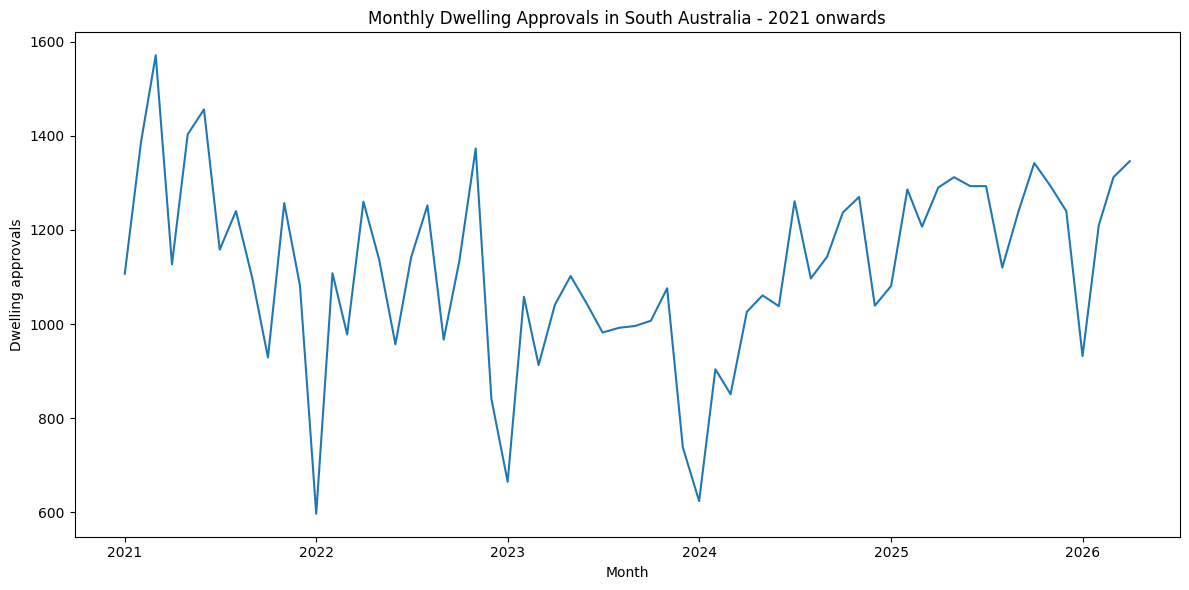

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

approvals = pd.read_csv("../data/processed/cleaned_building_approvals_sa.csv")

approvals["Month"] = pd.to_datetime(approvals["Month"])

plt.figure(figsize=(12, 6))
plt.plot(approvals["Month"], approvals["Dwelling_Approvals"])

plt.xlabel("Month")
plt.ylabel("Dwelling approvals")
plt.title("Monthly Dwelling Approvals in South Australia - 2021 onwards")
plt.tight_layout()

plt.savefig("../docs/monthly_dwelling_approvals_sa_2021_onwards.png", dpi=300, bbox_inches="tight")

plt.show()

In [47]:
approvals.head()

,Month,Dwelling_Approvals
0,2021-01-01,1107
1,2021-02-01,1387
2,2021-03-01,1571
3,2021-04-01,1127
4,2021-05-01,1403


In [48]:
approvals.tail()

,Month,Dwelling_Approvals
59,2025-12-01,1240
60,2026-01-01,932
61,2026-02-01,1210
62,2026-03-01,1312
63,2026-04-01,1346


In [49]:
import pandas as pd

rent = pd.read_csv("../data/processed/cleaned_rent_2025_12.csv")

rent_pressure = rent[[
    "Suburb",
    "Unit_Total_Median",
    "House_Total_Median",
    "Total_Median",
    "Total_Count"
]].copy()

rent_pressure = rent_pressure.dropna(subset=["Total_Median"])

rent_pressure = rent_pressure.sort_values(
    "Total_Median",
    ascending=False
)

rent_pressure.head(10)

,Suburb,Unit_Total_Median,House_Total_Median,Total_Median,Total_Count
246,Panorama,NaN,1000.0,1000.0,NaN
141,Heathpool,NaN,1000.0,1000.0,5.0
324,Stonyfell,NaN,1000.0,1000.0,NaN
323,Stirling,NaN,970.0,970.0,NaN
18,Belair,440.0,930.0,925.0,NaN
570,Red Banks,NaN,900.0,900.0,NaN
331,Teringie,570.0,1000.0,887.5,NaN
219,Netherby,415.0,1300.0,857.5,NaN
346,Uraidla,NaN,850.0,850.0,NaN
110,Gilberton,515.0,1100.0,842.5,10.0


In [50]:
def rent_pressure_category(rent_value):
    if rent_value >= 700:
        return "High"
    elif rent_value >= 550:
        return "Medium"
    else:
        return "Low"

rent_pressure["Rent_Pressure_Category"] = rent_pressure["Total_Median"].apply(rent_pressure_category)

rent_pressure.head()

,Suburb,Unit_Total_Median,House_Total_Median,Total_Median,Total_Count,Rent_Pressure_Category
246,Panorama,NaN,1000.0,1000.0,NaN,High
141,Heathpool,NaN,1000.0,1000.0,5.0,High
324,Stonyfell,NaN,1000.0,1000.0,NaN,High
323,Stirling,NaN,970.0,970.0,NaN,High
18,Belair,440.0,930.0,925.0,NaN,High


In [51]:
rent_pressure.to_csv(
    "../data/processed/dashboard_rent_pressure.csv",
    index=False
)

In [52]:
import os

os.listdir("../data/processed")

['dashboard_rent_pressure.csv',
 'cleaned_building_approvals_sa.csv',
 'cleaned_rent_2025_12.csv']

In [53]:
approvals = pd.read_csv("../data/processed/cleaned_building_approvals_sa.csv")

approvals["Month"] = pd.to_datetime(approvals["Month"])

approvals["Year"] = approvals["Month"].dt.year
approvals["Month_Name"] = approvals["Month"].dt.strftime("%b %Y")

approvals.head()

,Month,Dwelling_Approvals,Year,Month_Name
0,2021-01-01,1107,2021,Jan 2021
1,2021-02-01,1387,2021,Feb 2021
2,2021-03-01,1571,2021,Mar 2021
3,2021-04-01,1127,2021,Apr 2021
4,2021-05-01,1403,2021,May 2021


In [54]:
annual_approvals = (
    approvals
    .groupby("Year", as_index=False)["Dwelling_Approvals"]
    .sum()
)

annual_approvals

,Year,Dwelling_Approvals
0,2021,14815
1,2022,12747
2,2023,11613
3,2024,12551
4,2025,14997
5,2026,4800


In [55]:
annual_approvals.to_csv(
    "../data/processed/dashboard_annual_approvals.csv",
    index=False
)

In [56]:
approvals["Rolling_3_Month_Avg"] = approvals["Dwelling_Approvals"].rolling(window=3).mean()

approvals.to_csv(
    "../data/processed/dashboard_monthly_approvals.csv",
    index=False
)

approvals.tail()

,Month,Dwelling_Approvals,Year,Month_Name,Rolling_3_Month_Avg
59,2025-12-01,1240,2025,Dec 2025,1291.666667
60,2026-01-01,932,2026,Jan 2026,1155.000000
61,2026-02-01,1210,2026,Feb 2026,1127.333333
62,2026-03-01,1312,2026,Mar 2026,1151.333333
63,2026-04-01,1346,2026,Apr 2026,1289.333333


In [2]:
import pandas as pd

approvals = pd.read_csv("../data/processed/cleaned_building_approvals_sa.csv")

approvals["Month"] = pd.to_datetime(approvals["Month"])

approvals["Year"] = approvals["Month"].dt.year
approvals["Month_Name"] = approvals["Month"].dt.strftime("%b %Y")

approvals["Rolling_3_Month_Avg"] = approvals["Dwelling_Approvals"].rolling(window=3).mean()

approvals.to_csv(
    "../data/processed/dashboard_monthly_approvals.csv",
    index=False
)

approvals.tail()

,Month,Dwelling_Approvals,Year,Month_Name,Rolling_3_Month_Avg
59,2025-12-01,1240,2025,Dec 2025,1291.666667
60,2026-01-01,932,2026,Jan 2026,1155.000000
61,2026-02-01,1210,2026,Feb 2026,1127.333333
62,2026-03-01,1312,2026,Mar 2026,1151.333333
63,2026-04-01,1346,2026,Apr 2026,1289.333333


In [3]:
import os

os.listdir("../data/processed")

['dashboard_rent_pressure.csv',
 'cleaned_building_approvals_sa.csv',
 'dashboard_annual_approvals.csv',
 'cleaned_rent_2025_12.csv',
 'dashboard_monthly_approvals.csv']

In [4]:
approvals["Rolling_3_Month_Avg"] = approvals["Dwelling_Approvals"].rolling(window=3).mean()

approvals.to_csv(
    "../data/processed/dashboard_monthly_approvals.csv",
    index=False
)

approvals.tail()

,Month,Dwelling_Approvals,Year,Month_Name,Rolling_3_Month_Avg
59,2025-12-01,1240,2025,Dec 2025,1291.666667
60,2026-01-01,932,2026,Jan 2026,1155.000000
61,2026-02-01,1210,2026,Feb 2026,1127.333333
62,2026-03-01,1312,2026,Mar 2026,1151.333333
63,2026-04-01,1346,2026,Apr 2026,1289.333333


In [5]:
import os

os.listdir("../data/processed")

['dashboard_rent_pressure.csv',
 'cleaned_building_approvals_sa.csv',
 'dashboard_annual_approvals.csv',
 'cleaned_rent_2025_12.csv',
 'dashboard_monthly_approvals.csv']

## Milestone 4 — Housing Pressure Score

In [6]:
import pandas as pd
import numpy as np

rent_pressure = pd.read_csv("../data/processed/dashboard_rent_pressure.csv")

rent_pressure.head()

,Suburb,Unit_Total_Median,House_Total_Median,Total_Median,Total_Count,Rent_Pressure_Category
0,Panorama,NaN,1000.0,1000.0,NaN,High
1,Heathpool,NaN,1000.0,1000.0,5.0,High
2,Stonyfell,NaN,1000.0,1000.0,NaN,High
3,Stirling,NaN,970.0,970.0,NaN,High
4,Belair,440.0,930.0,925.0,NaN,High


In [7]:
def rent_score(value):
    if value >= 850:
        return 5
    elif value >= 750:
        return 4
    elif value >= 650:
        return 3
    elif value >= 550:
        return 2
    else:
        return 1

rent_pressure["Rent_Score"] = rent_pressure["Total_Median"].apply(rent_score)

rent_pressure.head()

,Suburb,Unit_Total_Median,House_Total_Median,Total_Median,Total_Count,Rent_Pressure_Category,Rent_Score
0,Panorama,NaN,1000.0,1000.0,NaN,High,5
1,Heathpool,NaN,1000.0,1000.0,5.0,High,5
2,Stonyfell,NaN,1000.0,1000.0,NaN,High,5
3,Stirling,NaN,970.0,970.0,NaN,High,5
4,Belair,440.0,930.0,925.0,NaN,High,5


In [8]:
rent_pressure["Housing_Pressure_Score"] = rent_pressure["Rent_Score"]

rent_pressure.head()

,Suburb,Unit_Total_Median,House_Total_Median,Total_Median,Total_Count,Rent_Pressure_Category,Rent_Score,Housing_Pressure_Score
0,Panorama,NaN,1000.0,1000.0,NaN,High,5,5
1,Heathpool,NaN,1000.0,1000.0,5.0,High,5,5
2,Stonyfell,NaN,1000.0,1000.0,NaN,High,5,5
3,Stirling,NaN,970.0,970.0,NaN,High,5,5
4,Belair,440.0,930.0,925.0,NaN,High,5,5


In [9]:
def housing_pressure_category(score):
    if score == 5:
        return "Very High"
    elif score == 4:
        return "High"
    elif score == 3:
        return "Medium"
    elif score == 2:
        return "Low"
    else:
        return "Very Low"

rent_pressure["Housing_Pressure_Category"] = rent_pressure["Housing_Pressure_Score"].apply(
    housing_pressure_category
)

rent_pressure.head()

,Suburb,Unit_Total_Median,House_Total_Median,Total_Median,Total_Count,Rent_Pressure_Category,Rent_Score,Housing_Pressure_Score,Housing_Pressure_Category
0,Panorama,NaN,1000.0,1000.0,NaN,High,5,5,Very High
1,Heathpool,NaN,1000.0,1000.0,5.0,High,5,5,Very High
2,Stonyfell,NaN,1000.0,1000.0,NaN,High,5,5,Very High
3,Stirling,NaN,970.0,970.0,NaN,High,5,5,Very High
4,Belair,440.0,930.0,925.0,NaN,High,5,5,Very High


In [10]:
rent_pressure = rent_pressure.drop(columns=["Rent_Pressure_Category"])

rent_pressure.head()

,Suburb,Unit_Total_Median,House_Total_Median,Total_Median,Total_Count,Rent_Score,Housing_Pressure_Score,Housing_Pressure_Category
0,Panorama,NaN,1000.0,1000.0,NaN,5,5,Very High
1,Heathpool,NaN,1000.0,1000.0,5.0,5,5,Very High
2,Stonyfell,NaN,1000.0,1000.0,NaN,5,5,Very High
3,Stirling,NaN,970.0,970.0,NaN,5,5,Very High
4,Belair,440.0,930.0,925.0,NaN,5,5,Very High


In [11]:
rent_pressure.to_csv(
    "../data/processed/dashboard_housing_pressure_score.csv",
    index=False
)

In [12]:
import os

os.listdir("../data/processed")

['dashboard_rent_pressure.csv',
 'dashboard_housing_pressure_score.csv',
 'cleaned_building_approvals_sa.csv',
 'dashboard_annual_approvals.csv',
 'cleaned_rent_2025_12.csv',
 'dashboard_monthly_approvals.csv']

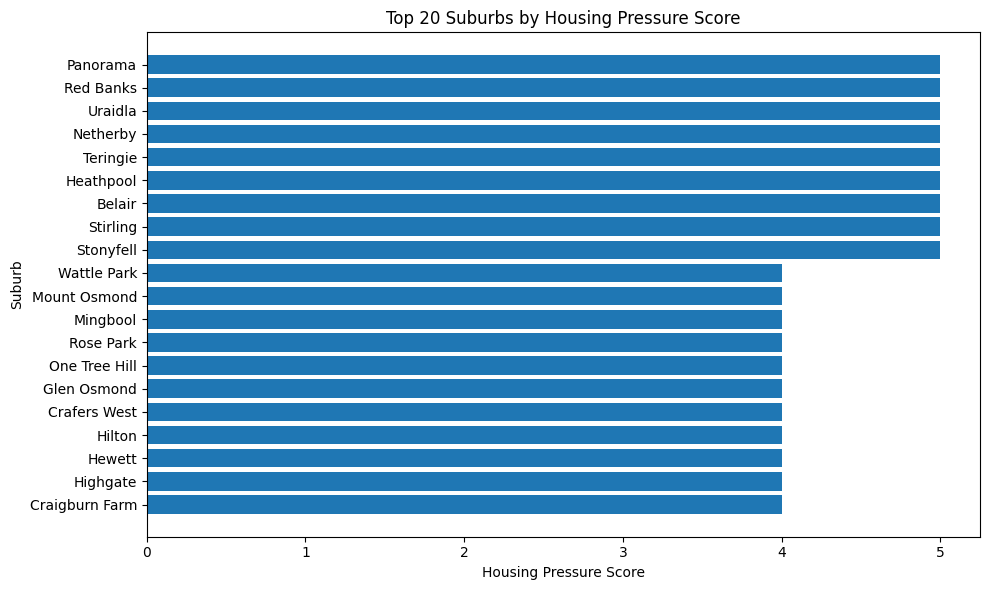

In [13]:
import matplotlib.pyplot as plt

top_pressure = rent_pressure.sort_values(
    "Housing_Pressure_Score",
    ascending=False
).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_pressure["Suburb"], top_pressure["Housing_Pressure_Score"])
plt.xlabel("Housing Pressure Score")
plt.ylabel("Suburb")
plt.title("Top 20 Suburbs by Housing Pressure Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

rent_file = "../data/raw/rent/private-rental-report-2025-12.xlsx"

rent_xls = pd.ExcelFile(rent_file)

rent_xls.sheet_names

['Suburb', 'PC', 'Region', 'SLA']

In [15]:
sla_preview = pd.read_excel(
    rent_file,
    sheet_name="SLA",
    header=None
)

sla_preview.head(20)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Source: Rental Bond Data Set of the Tenancies ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Notes:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"1. Excludes bonds that have been ""cancelled"" o...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2. Where there are 1 to 5 dwellings the number...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3. Flat/House totals have been rounded to the ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
region_preview = pd.read_excel(
    rent_file,
    sheet_name="Region",
    header=None
)

region_preview.head(20)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Source: Rental Bond Data Set of the Tenancies ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Notes:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"1. Excludes bonds that have been ""cancelled"" o...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2. Where there are 1 to 5 dwellings the number...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3. Flat/House totals have been rounded to the ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4. Metropolitan area is defined as the sum of ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
import os

os.listdir("../data/raw/approvals")

['.DS_Store',
 '87310do016_202604.xlsx',
 '8731004.xlsx',
 '.ipynb_checkpoints',
 '87310do017_202604.xlsx']

In [18]:
import pandas as pd

lga_2024_file = "../data/raw/approvals/87310do016_202604.xlsx"

lga_2024_xls = pd.ExcelFile(lga_2024_file)

lga_2024_xls.sheet_names

['Contents', 'Table_1']

In [19]:
lga_2024_preview = pd.read_excel(
    lga_2024_file,
    sheet_name=lga_2024_xls.sheet_names[0],
    header=None
)

lga_2024_preview.head(20)

,0,1
0,This tab outlines the contents of the datacube...,NaN
1,"87310DO016_202604 Building Approvals, Australi...",NaN
2,Released at 11:30 am (Canberra time) Wed 10 Ju...,NaN
3,Contents,NaN
4,Tab,Description
5,Table 1,"SA, LGA excel data cube, 2024-2025"
6,Further information,NaN
7,"This data comes from Building Approvals, Austr...",NaN
8,"Visit Building Approvals, Australia methodolog...",NaN
9,Australian Bureau of Statistics website,NaN


In [20]:
lga_2025_file = "../data/raw/approvals/87310do017_202604.xlsx"

lga_2025_xls = pd.ExcelFile(lga_2025_file)

lga_2025_xls.sheet_names

['Contents', 'Table_1']

In [21]:
lga_2025_preview = pd.read_excel(
    lga_2025_file,
    sheet_name=lga_2025_xls.sheet_names[0],
    header=None
)

lga_2025_preview.head(20)

,0,1
0,This tab outlines the contents of the datacube...,NaN
1,"87310DO017_202604 Building Approvals, Australi...",NaN
2,Released at 11:30 am (Canberra time) Wed 10 Ju...,NaN
3,Contents,NaN
4,Tab,Description
5,Table 1,"SA, LGA excel data cube, 2025-2026 FYTD"
6,Further information,NaN
7,"This data comes from Building Approvals, Austr...",NaN
8,"Visit Building Approvals, Australia methodolog...",NaN
9,Australian Bureau of Statistics website,NaN


In [22]:
lga_2024_xls.sheet_names

['Contents', 'Table_1']

In [23]:
lga_2024_preview.head(20)

,0,1
0,This tab outlines the contents of the datacube...,NaN
1,"87310DO016_202604 Building Approvals, Australi...",NaN
2,Released at 11:30 am (Canberra time) Wed 10 Ju...,NaN
3,Contents,NaN
4,Tab,Description
5,Table 1,"SA, LGA excel data cube, 2024-2025"
6,Further information,NaN
7,"This data comes from Building Approvals, Austr...",NaN
8,"Visit Building Approvals, Australia methodolog...",NaN
9,Australian Bureau of Statistics website,NaN


In [24]:
lga_2025_data = pd.read_excel(
    lga_2025_file,
    sheet_name="Table_1",
    header=None
)

lga_2025_data.head(30)

,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"87310DO017_202604 Building Approvals, Australi...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Released at 11:30 am (Canberra time) Wed 10 Ju...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Table 1. SA, LGA excel data cube, 2025-2026 FYTD",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,New houses,New other residential building,Total dwellings,Value of new houses,Value of new other residential building,Value of alterations & additions including con...,Value of total residential building,Value of non-residential building,Value of total building
5,NaN,NaN,no.,no.,no.,$'000,$'000,$'000,$'000,$'000,$'000
6,4,South Australia,8336,3878,12328,3621696,1494884,682479,5799058,5188500,10987558
7,40070,Adelaide,1,109,116,150,77800,22026,99976,1407951,1507927
8,40120,Adelaide Hills,77,0,82,56047,0,35571,91618,15005,106624
9,40150,Adelaide Plains,99,0,99,44368,0,4484,48852,13284,62136


In [25]:
lga_2025_data = pd.read_excel(
    lga_2025_file,
    sheet_name="Table_1",
    header=None
)

lga_2025_data.head(30)

,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"87310DO017_202604 Building Approvals, Australi...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Released at 11:30 am (Canberra time) Wed 10 Ju...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Table 1. SA, LGA excel data cube, 2025-2026 FYTD",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,New houses,New other residential building,Total dwellings,Value of new houses,Value of new other residential building,Value of alterations & additions including con...,Value of total residential building,Value of non-residential building,Value of total building
5,NaN,NaN,no.,no.,no.,$'000,$'000,$'000,$'000,$'000,$'000
6,4,South Australia,8336,3878,12328,3621696,1494884,682479,5799058,5188500,10987558
7,40070,Adelaide,1,109,116,150,77800,22026,99976,1407951,1507927
8,40120,Adelaide Hills,77,0,82,56047,0,35571,91618,15005,106624
9,40150,Adelaide Plains,99,0,99,44368,0,4484,48852,13284,62136


In [26]:
lga_2025_data.shape

(83, 11)

In [27]:
lga_2025_data.iloc[:30, :15]

,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"87310DO017_202604 Building Approvals, Australi...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Released at 11:30 am (Canberra time) Wed 10 Ju...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Table 1. SA, LGA excel data cube, 2025-2026 FYTD",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,New houses,New other residential building,Total dwellings,Value of new houses,Value of new other residential building,Value of alterations & additions including con...,Value of total residential building,Value of non-residential building,Value of total building
5,NaN,NaN,no.,no.,no.,$'000,$'000,$'000,$'000,$'000,$'000
6,4,South Australia,8336,3878,12328,3621696,1494884,682479,5799058,5188500,10987558
7,40070,Adelaide,1,109,116,150,77800,22026,99976,1407951,1507927
8,40120,Adelaide Hills,77,0,82,56047,0,35571,91618,15005,106624
9,40150,Adelaide Plains,99,0,99,44368,0,4484,48852,13284,62136
